## Legendre Polynomials

The Legendre polynomials arise naturally when solving Laplace’s equation in spherical coordinates. In particular, after separating variables, the angular equation reduces to Legendre’s differential equation:

$$
\frac{d}{dx}\left[(1-x^2)\frac{dP_\ell}{dx}\right]
+
\ell(\ell+1)P_\ell = 0
$$

Its solutions are the Legendre polynomials $P_\ell(x)$, where $\ell = 0,1,2,\dots$.

The first few Legendre polynomials are

$$ P_0(x)=1 $$

$$ P_1(x)=x $$

$$ P_2(x)=\frac12(3x^2-1) $$

$$ P_3(x)=\frac12(5x^3-3x) $$

The Legendre polynomials can be generated using Rodrigues' formula:

$$ P_\ell(x) = \frac{1}{2^\ell \ell!} \frac{d^\ell}{dx^\ell} (x^2-1)^\ell $$

These functions form an orthogonal basis on the interval $[-1,1]$:

$$ \int_{-1}^{1} P_\ell(x)P_{\ell'}(x)\,dx = 0, \qquad \ell\ne \ell' $$

Below, we plot the first few Legendre polynomials on the interval $[-1,1]$. As the order $\ell$ increases, the functions develop increasingly intricate oscillatory structure while remaining orthogonal over the interval.

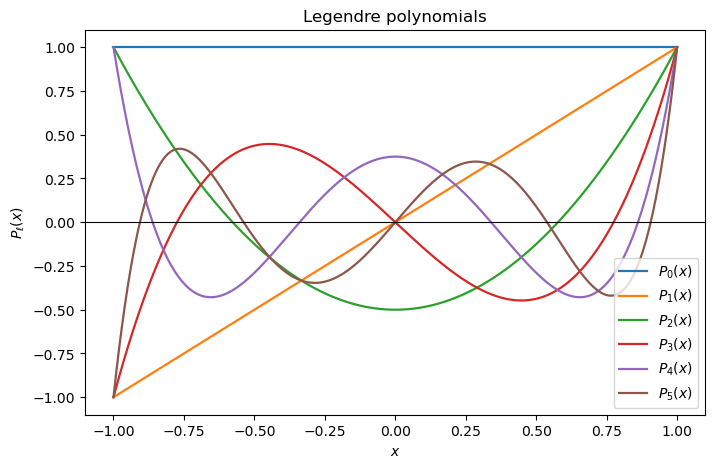

In [1]:
# Legendre polynomials

import numpy as np
import matplotlib.pyplot as plt
import scipy.special as ss

# Create x values on [-1,1]
x = np.linspace(-1, 1, 1000)

# Create figure
fig, ax = plt.subplots(figsize = (8, 5))

# Plot several Legendre polynomials
for ell in range(6):

    P = ss.eval_legendre(ell, x)

    ax.plot(
        x,
        P,
        linewidth = 1.6,
        label = rf"$P_{{{ell}}}(x)$"
    )

# Horizontal axis
ax.axhline(
    0,
    color = "black",
    linewidth = 0.8
)

# Labels
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$P_\ell(x)$")

# Title
ax.set_title("Legendre polynomials")

# Legend
ax.legend()

plt.show()

## Associated Legendre Functions

The associated Legendre functions appear when the angular part of a spherical-coordinate problem has both a polar angle $\theta$ and an azimuthal angle $\phi$. They generalize the ordinary Legendre polynomials by introducing a second integer index $m$:

$$
P_\ell^m(x)
$$

where $0 \le m \le \ell$ and

$$ P_{\ell}^{m}(x) = (-1)^m(1-x^2)^{m/2} \left( \frac{d}{dx} \right)^m P_{\ell}(x) $$

In spherical coordinates, we usually evaluate them at

$$
x = \cos\theta
$$

so the polar angular dependence becomes

$$
P_\ell^m(\cos\theta)
$$

For fixed $\ell$, different values of $m$ change the angular structure in the $\theta$ direction. These functions are one of the main ingredients in the spherical harmonics:

$$
Y_\ell^m(\theta,\phi)
$$

Below, we fix $\ell=3$ and plot $P_3^m(\cos\theta)$ for several values of $m$.

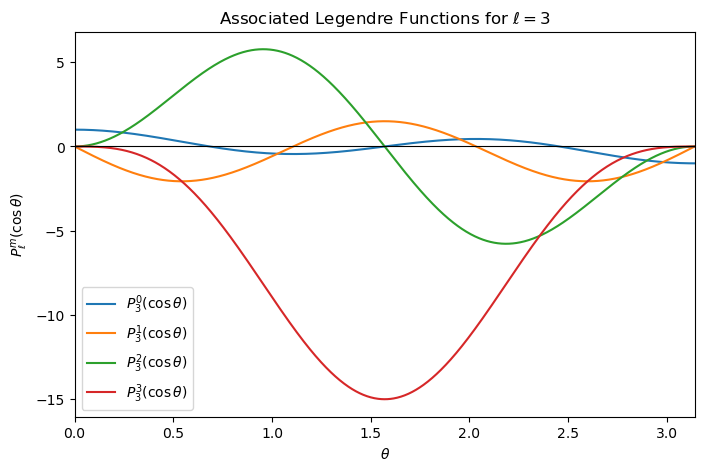

In [3]:
# Associated Legendre Function Plots

# Polar angle
theta = np.linspace(0, np.pi, 1000)

# Fixed ell value
ell = 3

# Allowed m values for this ell
ms = [0, 1, 2, 3]

plt.figure(figsize = (8, 5))

for m in ms:

    # Associated Legendre function P_ell^m(cos(theta))
    #
    # These functions describe the theta-dependent part
    # of the spherical harmonics
    P_lm = ss.lpmv(m, ell, np.cos(theta))

    plt.plot(
        theta,
        P_lm,
        linewidth = 1.5,
        label = rf"$P_{{{ell}}}^{{{m}}}(\cos\theta)$"
    )

plt.xlim(0, np.pi)

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P_\ell^m(\cos\theta)$")
plt.title(rf"Associated Legendre Functions for $\ell={ell}$")

plt.legend()

plt.show()

## Spherical Harmonic Surface Plots

Spherical harmonics combine the associated Legendre functions with an azimuthal phase factor. They have the general form

$$ Y_\ell^m(\theta,\phi) = N_{\ell m} P_\ell^m(\cos\theta)e^{im\phi} $$

where $N_{\ell m}$ is a normalization constant.

These functions describe angular patterns on the surface of a sphere. To visualize their structure, we use the magnitude of the spherical harmonic to deform the radius of the sphere:

$$
r(\theta,\phi)=|Y_\ell^m(\theta,\phi)|
$$

This does not mean the spherical harmonic is literally a three-dimensional object. Rather, the surface provides a geometric visualization of the angular dependence of the eigenfunction. Directions in which the spherical harmonic has larger magnitude produce outward lobes, while regions of smaller magnitude remain closer to the center. The resulting patterns foreshadow the angular structure that later appears in hydrogen atom orbitals and angular momentum eigenstates.

Below, we plot a few low-order spherical harmonics using this radial deformation.

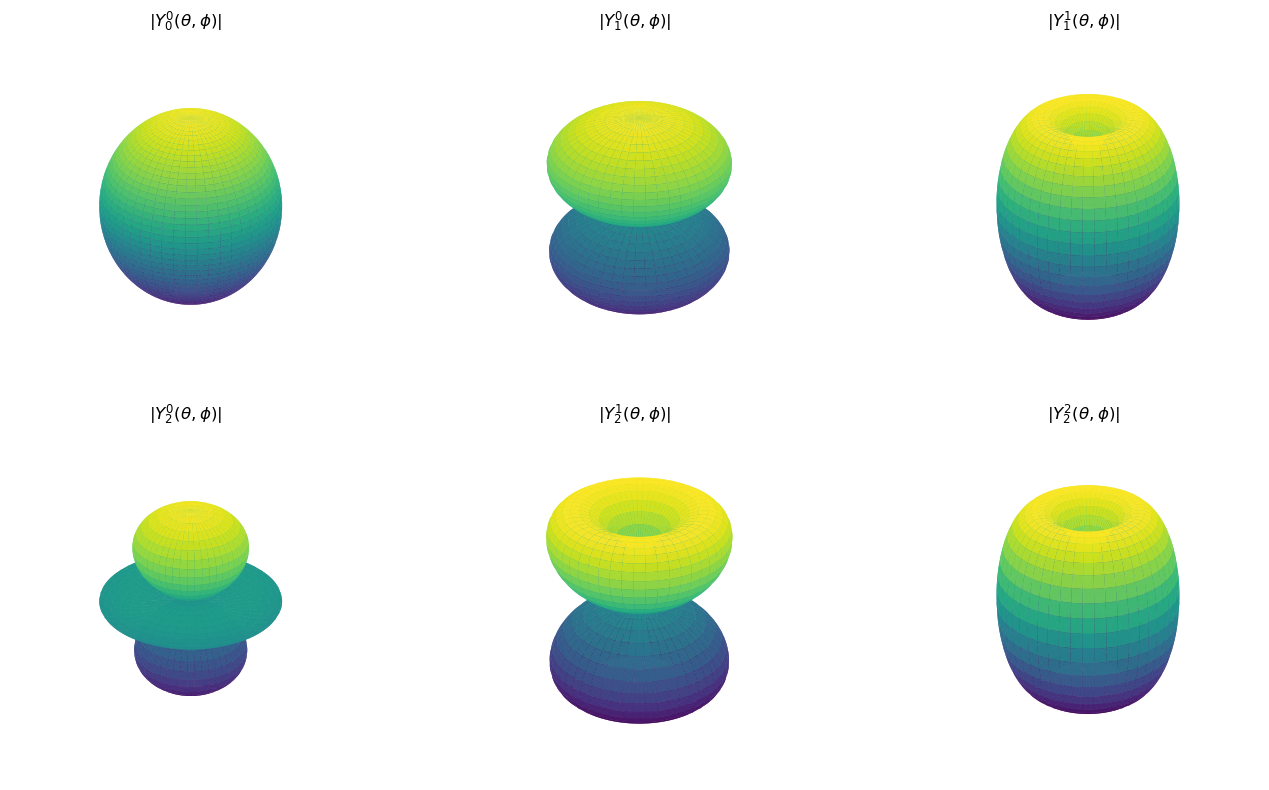

In [4]:
# Spherical Harmonic Surface Plots

# Angular grids
theta = np.linspace(0, np.pi, 200)      # polar angle
phi = np.linspace(0, 2*np.pi, 200)      # azimuthal angle

theta, phi = np.meshgrid(theta, phi)

# Spherical harmonics to visualize
harmonics = [
    (0, 0),
    (1, 0),
    (1, 1),
    (2, 0),
    (2, 1),
    (2, 2)
]

fig = plt.figure(figsize=(14, 8))

for i, (ell, m) in enumerate(harmonics, start=1):

    # Compute the spherical harmonic Y_l^m(theta, phi)
    #
    # SciPy's newer sph_harm_y function uses the argument order:
    # sph_harm_y(ell, m, theta, phi)
    #
    # Here theta is the polar angle and phi is the azimuthal angle
    Y_lm = ss.sph_harm_y(ell, m, theta, phi)

    # Use the magnitude of the spherical harmonic as the radius
    #
    # This turns an angular function on the sphere into a
    # three-dimensional lobe plot
    r = np.abs(Y_lm)

    # Convert from spherical coordinates to Cartesian coordinates
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)

    ax = fig.add_subplot(2, 3, i, projection="3d")

    ax.plot_surface(
        x,
        y,
        z,
        cmap="viridis",
        edgecolor="none",
        alpha=0.95
    )

    ax.set_title(
        rf"$|Y_{{{ell}}}^{{{m}}}(\theta,\phi)|$"
    )

    # Keep the x, y, and z directions visually proportional
    ax.set_box_aspect([1, 1, 1])

    ax.set_axis_off()

plt.tight_layout()
plt.show()